# Fund Workstation

## Pre-Analysis Loading

#### Environment Setting

In [1]:
import pandas as pd
import plotly.graph_objects as go
from src.fofproject.fund import Fund, input_monthly_returns, subset_of_funds, compare_funds
from fofproject.batch import plot_cumulative_returns, plot_fund_correlation_heatmap
from src.fofproject.mvo import minimum_variance_analysis
from src.fofproject.load import load_saved_json, init_funds, process_pdfs_in_folder, save_changes_in_fund, merge_funds, rerun_no_perf_files, continue_running

# Names of our portfolio & benchmark indices
our_portfolio = ['TAIREN','HAO','LEXINGTON','LIM','FOREST','WT CHINA','E20','3W GLOBAL','3W CHINA','3W HEALTHCARE','TIMEFOLIO','MONOLITH','PERSEVERANCE','NEO IVY','JH BIOTECH']
our_index = ['EUREKAHEDGE WORLD', 'MSCI CHINA',	'MSCI WORLD', 'EUREKAHEDGE ASIA', 'TOPIX', 'S&P 500', 'SOX', 'KOSPI', 'TAIEX', 'MSCI EM', 'RUSSELL 2000', 'STOXX 600', 'STOXX 50', 'FTSE UK', 'US HEALTHCARE', 'US FINANCIAL', 'US ENERGY', 'COMMODITY']

#### Load Data via .json

In [26]:
test = load_saved_json(folder_path=r"input\forest avenue")
forest_avenue = init_funds(test)


In [16]:
port = load_saved_json(folder_path=r"input\individual investigation")
statar = init_funds(port)


#### Load Data via .csv

In [4]:
# Use for manually update csv data and merge with json file 
csv_fund = input_monthly_returns(r"RETURN DATA.csv")

#### GPT Input Factsheet

##### Parse Everything

In [ ]:
# Do not open the pdf while running, or the renaming process will encounter error
gpt_fund = process_pdfs_in_folder(folder_path=r"input\individual investigation",save=True)
forest_avenue = init_funds(gpt_fund)

Processing: input\forest avenue\Forest Avenue Capital Monthly Performance Report September 2025 - River Delta.pdf
No valid year found in ['Standard Tranche', '6.10%', '-3.98%', '-7.92%', '6.57%', '6.85%', '8.53%', '-1.30%', '-0.55%', '1.63%', '', '', '', '15.64%', '114.38%'], appending 2025
No valid year found in ['Founders Tranche D', '6.29%', '-4.46%', '-7.63%', '6.57%', '7.06%', '8.78%', '-1.32%', '-0.53%', '6.30%', '-4.45%', '-7.60%', '6.59%', '16.37%', '128.24%'], appending 2024
No valid year found in ['Founders Tranche C', '6.40%', '-4.54%', '-7.65%', '6.57%', '7.19%', '8.93%', '-1.34%', '-0.56%', '1.72%', '', '', '', '16.48%', '129.70%'], appending 2023
No valid year found in ['Founders Tranche B', '8.95%', '-1.32%', '-0.54%', '1.74%', '', '', '', '16.67%', '131.21%', '', '', '', '', ''], appending 2022
No valid year found in ['Founders Tranche A', '6.42%', '-4.52%', '-7.63%', '6.59%', '7.20%', '', '', '', '', '', '', '', '', ''], appending 2021
Non-number found in FOREST's earl

##### Continue Running Unparsed

In [36]:
gpt_fund_2 = continue_running(folder_path=r"input\individual investigation",save=True)
gpt_fund_2 = init_funds(gpt_fund_2)

Processing: input\individual investigation\ILS_presentation.pdf


In [ ]:
gpt_fund = gpt_fund_2 | gpt_fund

##### Re-Run No Performance Funds

In [22]:
# Target the files with "No Performance Found", and re-run the analysis again
rerun_no_perf_files(folder_path=r"input\forest avenue",save=True)

Re-processing (no performance before): input\forest avenue\FOREST_parsed from_Forest Avenue Capital Monthly Performance Report September 2025 - River Delta.pdf
No valid year found in ['Standard Tranche', '0.0610', '-0.0398', '-0.0792', '0.0657', '0.0685', '0.0853', '-0.0130', '-0.0055', '0.0163', '', '', '', '0.1564', '1.1438'], appending 2025
No valid year found in ['Founders Tranche D', '0.0629', '-0.0446', '-0.0763', '0.0657', '0.0706', '0.0878', '-0.0132', '-0.0053', '0.0630', '-0.0445', '-0.0760', '0.0659', '0.1637', '1.2824'], appending 2024
No valid year found in ['Founders Tranche C', '0.0640', '-0.0454', '-0.0765', '0.0657', '0.0719', '0.0893', '-0.0134', '-0.0056', '0.0172', '', '', '', '0.1648', '1.2970'], appending 2023
No valid year found in ['Founders Tranche B', '0.0895', '-0.0132', '-0.0054', '0.0174', '', '', '', '0.1667', '', '', '', '', '0.1321', ''], appending 2022
No valid year found in ['Founders Tranche A', '0.0642', '-0.0452', '-0.0763', '0.0659', '0.0720', '', 

[{'fund_name': 'FOREST',
  'fund_des': 'FOREST is a global equity long short investment firm founded by Tarigh Yusufi, focusing on secular themes and compelling long and short opportunities across energy, industrials, infrastructure, materials, and consumer sectors. The fund aims to generate superior, consistent returns uncorrelated to market conditions through fundamentally researched portfolios. Launched in September 2022, it emphasizes idiosyncratic investments. Rating: 4, overall positive view.',
  'performance': [],
  'investment_location': ['global'],
  'investment_strategy': ['equity_ls'],
  'investment_sector': ['equity_energy',
   'equity_industrials',
   'equity_consumer'],
  'manager_names': ['Tarigh Yusufi'],
  'manager_profiles': {'Tarigh Yusufi': {'summary': 'Founder and key manager of Forest Avenue Capital Management, responsible for global equity long short strategy.',
    'location': 'NaN',
    'years_of_experience': 0}},
  'contact': {'name': '', 'location': '', 'emai

#### Merging Different Input

In [5]:
# Use the left hand's PERFORMANCE TABLE to update the right hand one
funds = merge_funds(csv_fund, funds)

In [37]:
# Right-hand side has higher priority
funds = funds | gpt_fund_2

#### Save the Changes to .json & .csv

In [ ]:
# Careful what fund you are saving to what folder
save_changes_in_fund(funds, folder_path=r"input\worth_a_look")

In [ ]:
print(funds['ASIAN TECHNOLOGY'].total_max_dd)

## Fund Analysis

#### Dataframe Comparison

In [40]:
df = compare_funds(funds)
do_not_display = our_index + our_portfolio
df = df[~df["Name"].isin(do_not_display)].reset_index(drop=True)
print(df)


                   Name                                        Description  \
0                   ARB  Melanion Arb Fund specializes in dividend futu...   
1           BLUE RIBAND  Blue Riband Fund LP is a concentrated, high-co...   
2             HYPERNOVA  The Io Hypernova Fund is an inflation/macro tr...   
3                 MEDIT  MEDIT is a generalist long/short hedge fund fo...   
4               ORGUEIL  ORGUEIL is a global equity fund focusing on op...   
5            PROMERITUM  ProMeritum EM Segregated Portfolio is a macro ...   
6                 SHARC  SHARC is a long-short commodity futures fund u...   
7              SHIPROCK  SHIPROCK is a London-based global distressed a...   
8                 TOSCA  Tosca Focus aims for superior total return thr...   
9                  TSCI  TSCI is a monthly liquidity fund investing in ...   
10                RDGFF                                               None   
11  ALPHA OPPORTUNITIES  ALPHA OPPORTUNITIES is a multi-strategy

In [ ]:
# Column List = ["Name", "Description", "Location", "Strategy", "Sector", "Managers", "Contact", "AUM (in Mn USD)", 
#                     "Net Exposure", "Net Return", "Mgmt Fee", "Perf Fee", "Inception Date", "Latest Date", "Month Running",
#                     "# Months", "Cumulative Return", "Annualized Return", "Volatility", "Sharpe Ratio", 
#                     "Sortino Ratio", "Max Drawdown", "Positive Months"]


In [8]:
# sort by what we think important   
df = df.sort_values(by=["Sharpe Ratio", "Annualized Return"], ascending=[False, False])
# mask and filtered only the wanted funds
mask =  (df["Month Running"] > 6) & (df["Annualized Return"] > 0.12)
df['Worth a Look'] = mask
# Display only the following columns
display_df = df[["Worth a Look","Name", "Sharpe Ratio", "Annualized Return", "AUM (in Mn USD)", "Month Running","Description","Max Drawdown" ]]
display_df


,Worth a Look,Name,Sharpe Ratio,Annualized Return,AUM (in Mn USD),Month Running,Description,Max Drawdown
8,True,TOSCA,3.024070,0.129571,0.00,192.766667,Tosca Focus aims for superior total return thr...,0.015515
7,True,SHIPROCK,2.492663,0.236850,1050.00,31.433333,SHIPROCK is a London-based global distressed a...,0.087378
5,True,PROMERITUM,2.250194,0.158477,200.00,19.300000,ProMeritum EM Enhanced Feeder Fund is a macro ...,0.059256
4,True,ORGUEIL,1.877879,0.418127,83.97,15.200000,ORGUEIL is a global equity fund focusing on op...,0.098517
3,True,MEDIT,1.763269,0.182703,105.00,28.466667,MEDIT is a generalist long/short hedge fund fo...,0.085672
10,True,RDGFF,1.495019,0.152524,NaN,93.333333,None,0.078768
6,True,SHARC,1.439767,0.213001,84.00,40.600000,SHARC is a long-short commodity futures fund u...,0.128376
0,True,ARB,1.288698,0.458938,13.20,63.933333,Melanion Arb Fund specializes in dividend futu...,0.465977
2,True,HYPERNOVA,1.132762,0.159586,350.00,54.733333,The Io Hypernova Fund is an inflation/macro tr...,0.148637
1,True,BLUE RIBAND,0.914634,0.296369,0.00,90.333333,"Blue Riband Fund LP is a concentrated, high-co...",0.470680


#### Save it to CSV

In [25]:
# Select the column you want to save
output_df = df[["Worth a Look","Name", "Sharpe Ratio", "Annualized Return", "AUM (in Mn USD)", "Month Running","Max Drawdown" ,"Net Exposure","Strategy", "Sector","Contact","Description", "Mgmt Fee", "Perf Fee"]]
output_df.to_csv("output/funds_comparison.csv", index=False)

#### Save it to a list

In [ ]:
exclude_list = our_index + our_portfolio
df = df[~df["Name"].isin(exclude_list)].reset_index(drop=True)
worth_looking = df.loc[df["Worth a Look"], "Name"].tolist()
print(worth_looking)

#### Compare Performance Table

In [ ]:
funds['ONELS'].export_monthly_table(benchmark_fund = funds['MSCI CHINA'], benchmark_name = "MSCI\nChina" ,language = "en", inception_column = True)

#### Plot Cumulative Return

In [11]:

funds_to_be_plot = subset_of_funds(funds, ['QUANTICA', 'RDGFF', 'US FINANCIAL'])
start_month = "2000-12"
end_month = "2025-9"

plot = plot_cumulative_returns(
    funds=funds_to_be_plot,
    title="",
    start_month=start_month,
    end_month=end_month,
    style="excel",
    language="en",
    blur=False,
    aspect_lock=True,
    custom_ticks=False,
    save=False,
    toggle=False
    )


#### Correlation Heat Map

In [ ]:
# Correlation heatmap

start_month = "2019-12"
end_month = "2025-7"

fig, corr_df, overlap_df = plot_fund_correlation_heatmap(funds_to_be_plot, method="pearson", min_overlap=12)

#### Efficient Frontier Analysis

In [23]:
remove_list = ['RDGFF', 'E20']

for i, k in enumerate(our_portfolio):
    if k in remove_list:
        our_portfolio.pop(i)
test =  ['RDGFF', 'QUANTICA']
print(our_portfolio)


funds_to_be_plot = subset_of_funds(funds, test)
print(len(funds))

['TAIREN', 'HAO', 'LEXINGTON', 'LIM', 'FOREST', 'WT CHINA', '3W GLOBAL', '3W CHINA', '3W HEALTHCARE', 'TIMEFOLIO', 'MONOLITH', 'PERSEVERANCE', 'NEO IVY', 'JH BIOTECH', 'QUANTICA']
35


In [24]:
# Choose Mode between "Maximum Sharpe", "Minimum Variance", "Target Return"
fig, weights, stats = minimum_variance_analysis(funds=funds_to_be_plot, mode="Maximum Sharpe", title=None)
print(weights)
print(stats)

Expected annual return: 13.5%
Annual volatility: 74.9%
Sharpe Ratio: 0.18


OrderedDict({'RDGFF': 0.5969182857139664, 'QUANTICA': 0.4030817142860337})
{'n_months': 93, 'Volatility': np.float64(0.7492220065039944), 'Expected Return': np.float64(0.13535064272579878), 'Sharpe': np.float64(0.18065492143960024)}


#### Summary of a Fund

SECURIS is a leading insurance-linked securities (ILS) investment manager specializing in catastrophe risk premia through a diversified portfolio of non-life ILS. The fund employs a dynamic, multi-segment approach focusing on mid-risk tranches with managed tail risk, targeting SOFR +8-12% net return. It leverages proprietary technology and research-driven insights with a strong team experienced in capital markets, catastrophe risk modelling, and reinsurance underwriting. The fund emphasizes risk mitigation, market cycle management, and structural innovation. Rating: 4, overall positive outlook.
Net Exposure = 0% to 0%
Client Services - Based in , try reachout via email 'info@twelvesecuris.com' or phone ''
Chart saved to SECURIS_vs_MSCI WORLD_Fund Performance on Benchmark's Worst Days.png


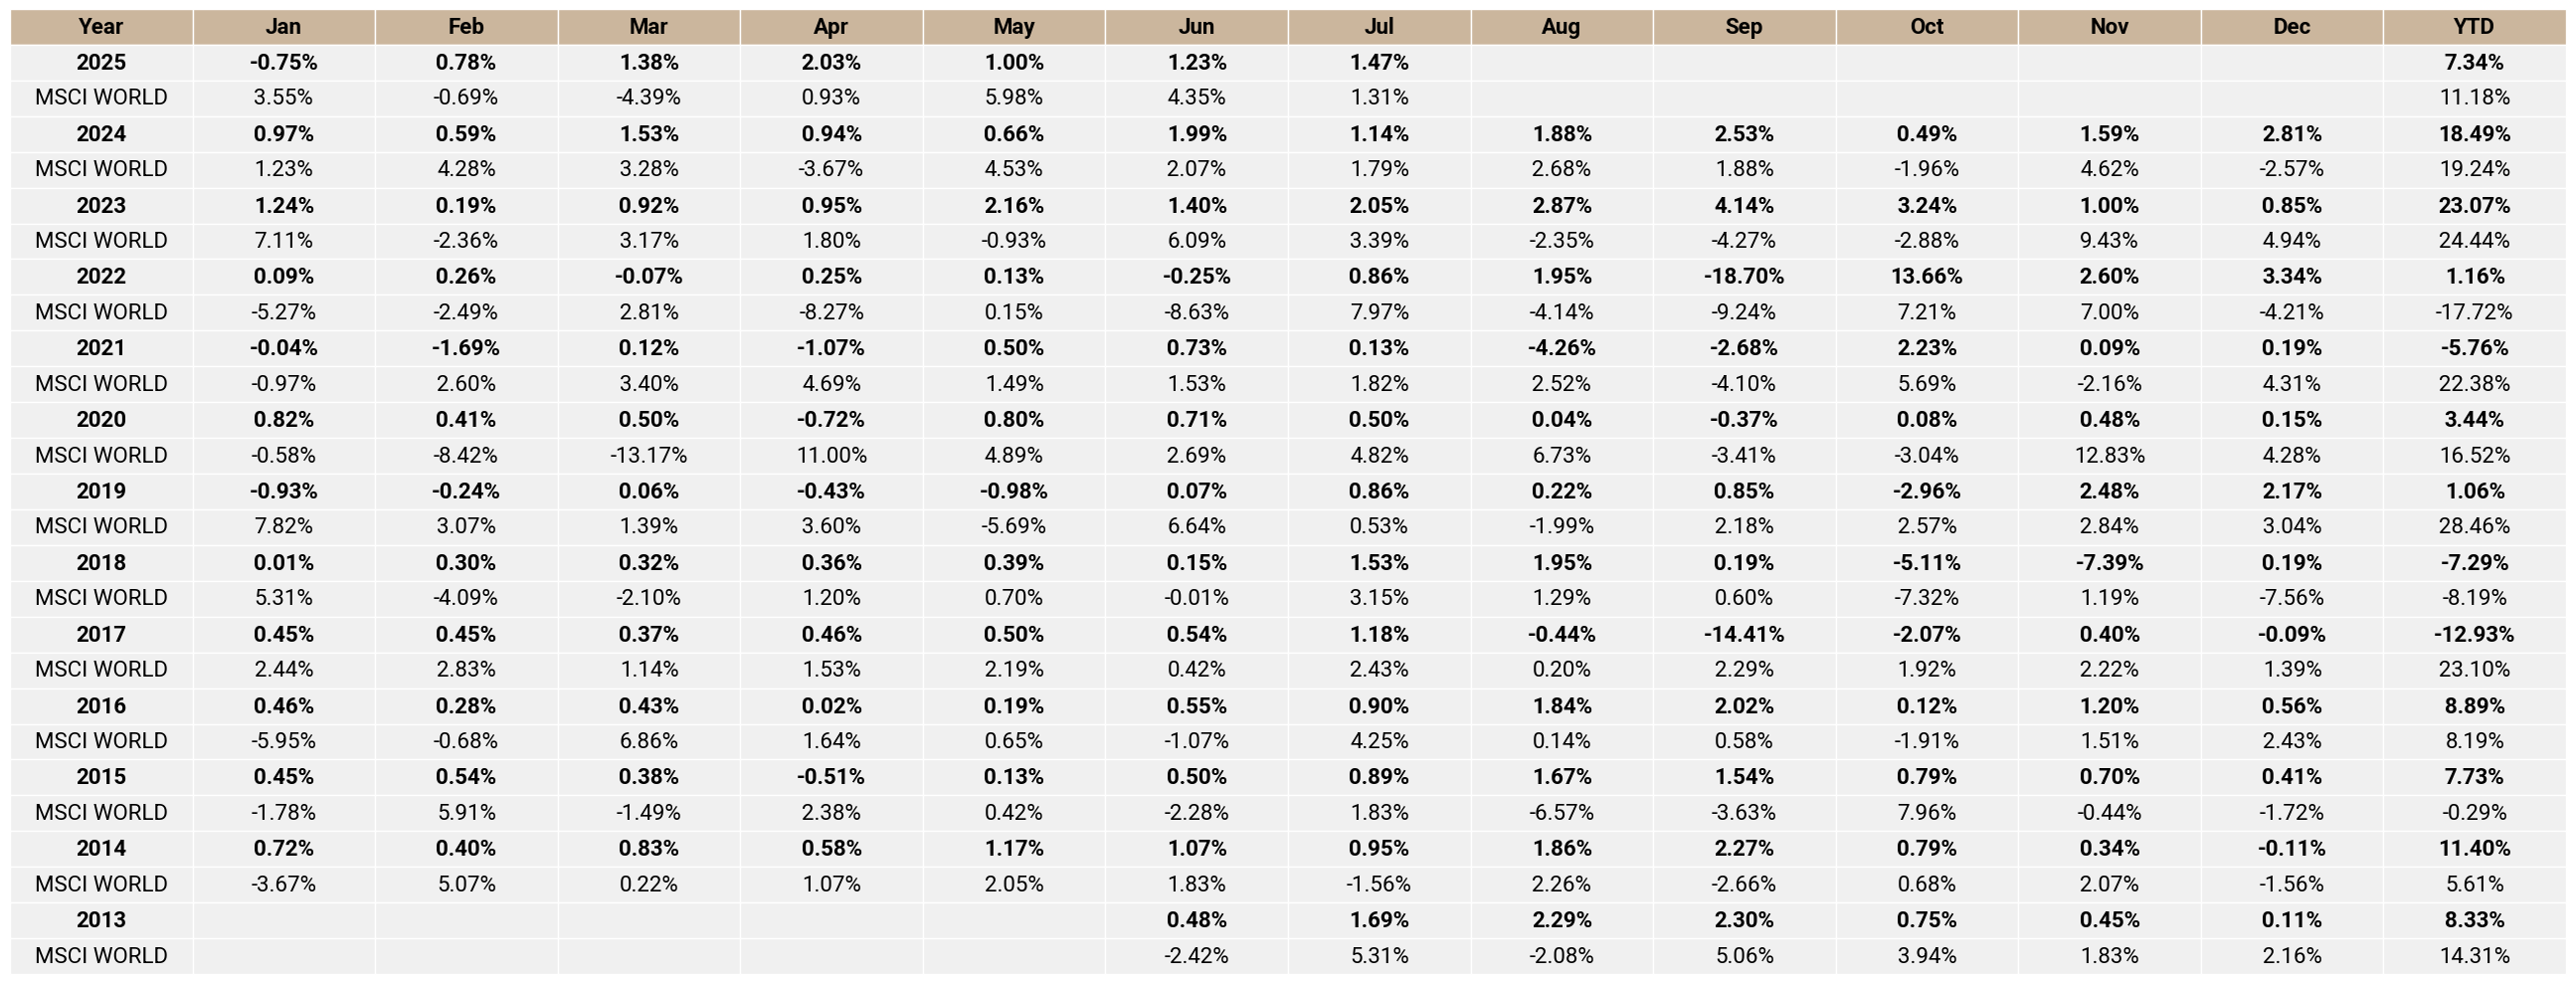

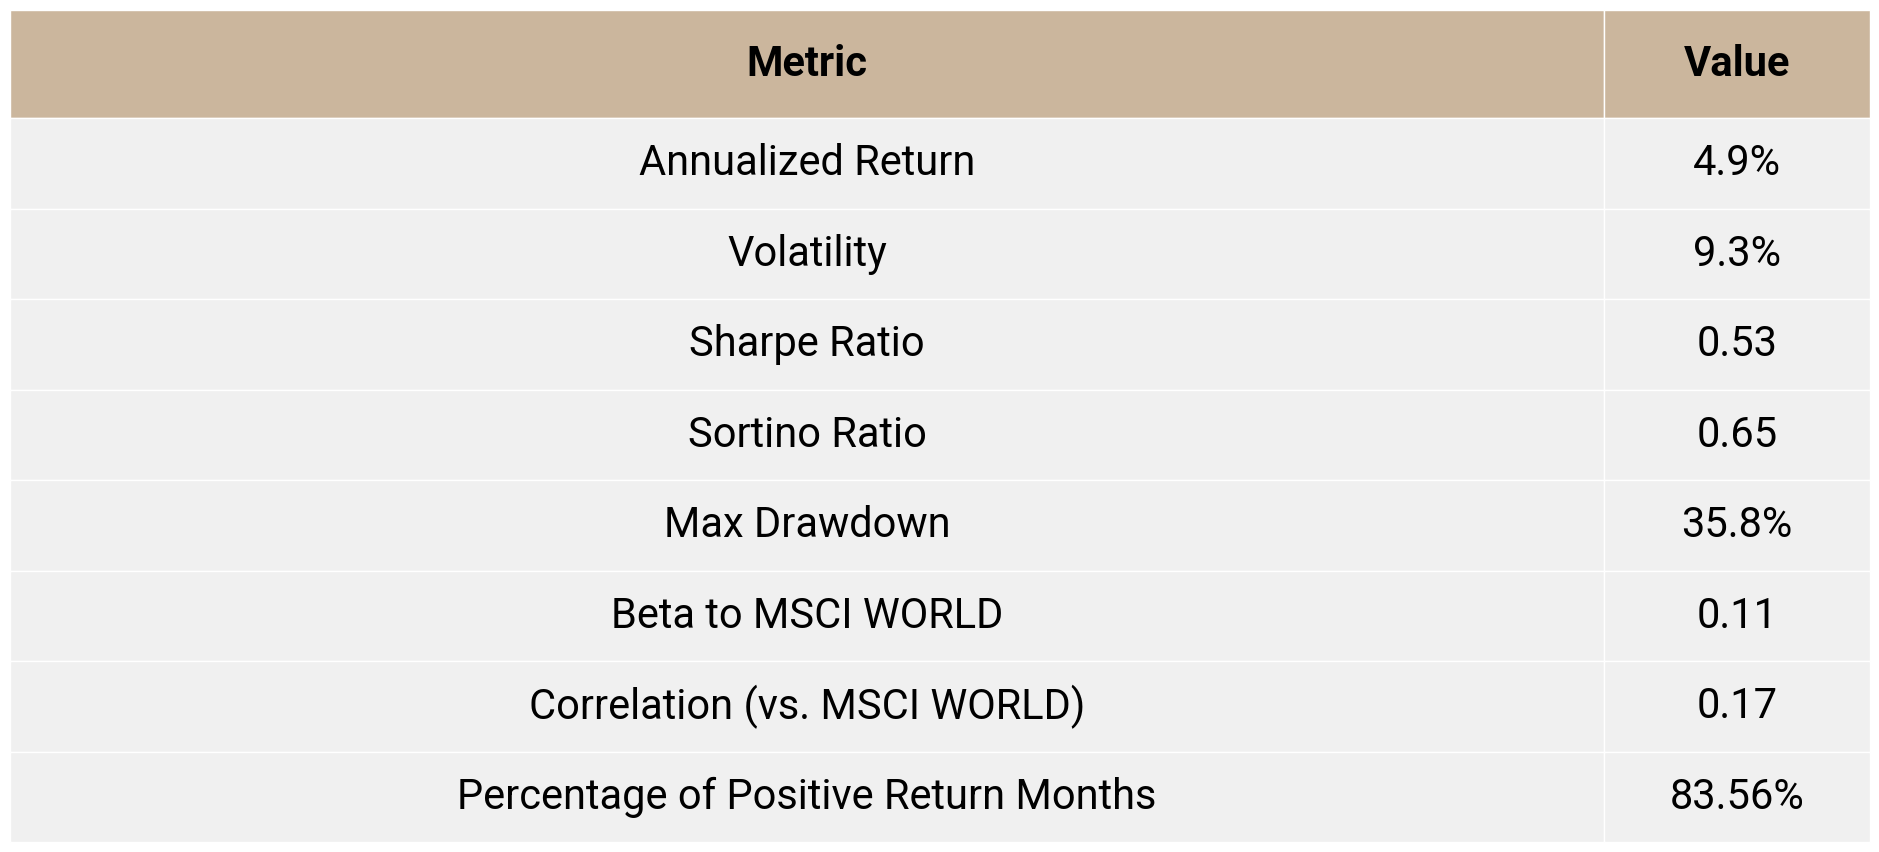

C:\Users\FOF Analyst\Desktop\fofproject\src\fofproject\fund.py:1587: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



Chart saved to SECURIS_vs_RDGFF_Fund Performance on Benchmark's Worst Days.png
Chart saved to SECURIS_vs_RDGFF_Entire performance compared with our fund's.png


In [42]:
# for f in ['DC', 'PROTIUM OPPORTUNITIES', 'FORWARDEDGE', 'ALPHA OPPORTUNITIES', 'ASIA ABSOLUTE', 'REGAL TACTICAL', 'PANVIEW', 'DKAM GLOBAL', 'AURIGIN', 'RDGFF', 'DUNAMIS', 'FRONTIER', 'HEL VED']:
fund_name = 'SECURIS'
funds[fund_name].summary_of_a_fund(benchmark_fund=funds['MSCI WORLD'],language="en",save=True)
funds[fund_name].compare_worst_performance(funds['RDGFF'], n_worst=10,  save=True)
funds[fund_name].compare_worst_performance(funds['RDGFF'], title="Entire performance compared with our fund's" ,n_worst=100,  save=True)

#### Quick Investigation

In [35]:
for a in our_index:
    print(f'The correlation with {a} is {funds['FOREST AVENUE'].correlation_to(funds[a], funds['FOREST AVENUE'].inception_date,funds['FOREST AVENUE'].latest_date)}' )

The correlation with EUREKAHEDGE WORLD is 0.5177039403417869
The correlation with MSCI CHINA is -0.02134450637546316
The correlation with MSCI WORLD is 0.40699291725696457
The correlation with EUREKAHEDGE ASIA is 0.19009814362377386
The correlation with TOPIX is 0.15141611691287613
The correlation with S&P 500 is 0.4308025251973605
The correlation with SOX is 0.370503447822047
The correlation with KOSPI is 0.20924034684645387
The correlation with TAIEX is 0.23170499604335396
The correlation with MSCI EM is 0.1277622200640374
The correlation with RUSSELL 2000 is 0.4697611937877155
The correlation with STOXX 600 is 0.27360568098363386
The correlation with STOXX 50 is 0.2059587774419496
The correlation with FTSE UK is 0.27165571770126207
The correlation with US HEALTHCARE is 0.10866702826595077
The correlation with US FINANCIAL is 0.41137144961807076
The correlation with US ENERGY is 0.0598370087540639
The correlation with COMMODITY is 0.1007118489033451


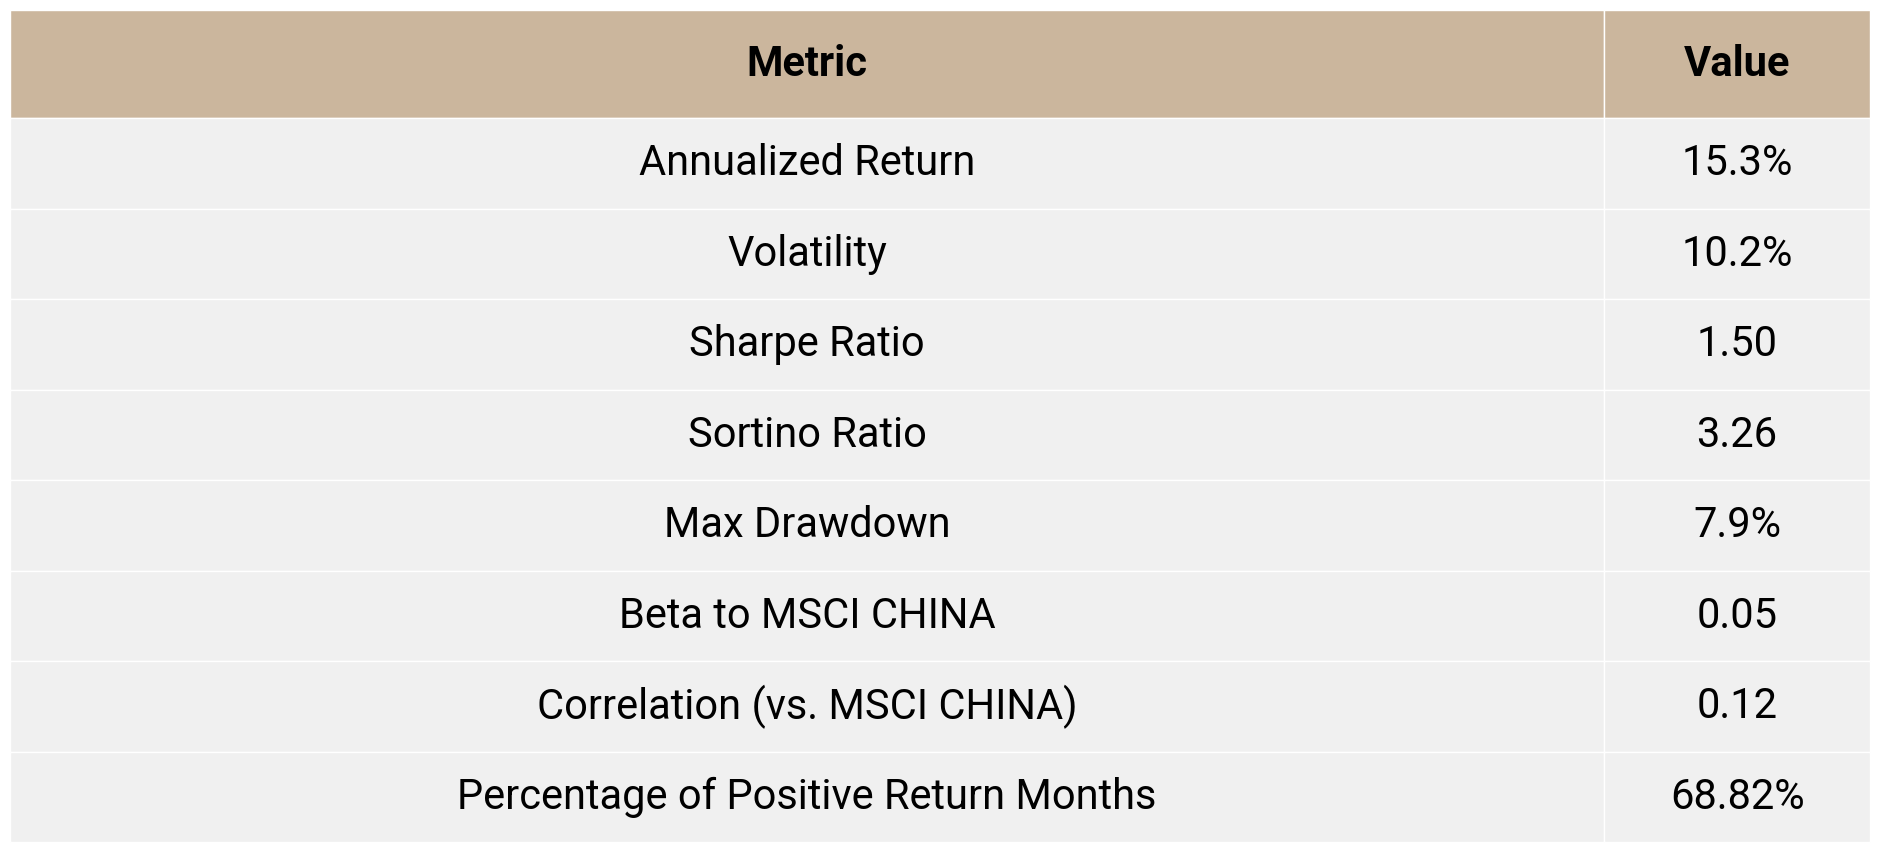

In [ ]:
the_fund_to_investigate = funds['RDGFF']
benchmark_fund = funds['MSCI CHINA']
# The List = ["cagr","vol","sharpe","sortino","mdd","beta","corr","win","best","worst","aum","skew","kurt","turnover"]



fig1 = the_fund_to_investigate.export_key_metrics_table(
            benchmark_fund=benchmark_fund,
            end_month=the_fund_to_investigate.latest_date,
            language="en",
            metrics=["cagr", "vol", "sharpe", "sortino", "mdd", "beta", "corr", "win"],
            horizontal=False,
        )

fig2 = compa